# AC1 — Regressão Linear Múltipla: Corn Growth

**Disciplina:** Reconhecimento de Padrões

**Aluno:** Giovanne Vieira de Queiroz, 235969. TIN3.

**Dataset:** [Corn Crop Growth (Kaggle)](https://www.kaggle.com/datasets/miguelh65/corn-crop-growth) — 1000 registros de plantação de milho coletados por sensores.

**Objetivo:** demonstrar as etapas de um projeto de Machine Learning — aquisição e pré-processamento dos dados, treinamento de um modelo de Regressão Linear e avaliação/interpretação das métricas de desempenho.

| Variável | Papel | Descrição |
|---|---|---|
| `Temperature` | Preditor (X) | Temperatura do ambiente |
| `Humidity` | Preditor (X) | Umidade do ar |
| `Soil_Moisture` | Preditor (X) | Umidade do solo |
| `Growth` | **Alvo (y)** | Crescimento da cultura |

**Etapas da atividade**

1. **Q1 — Aquisição e Pré-processamento dos Dados**
2. **Q2 — Treinamento do Modelo**
3. **Q3 — Avaliação das Métricas e Interpretação**


## 0. Instalação e importação de dependências

In [ ]:
!pip install -r requirements

In [23]:
import pandas as pd
import pandera.pandas as pa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import math

## Q1 — Aquisição e Pré-processamento dos Dados (30%)

Nesta etapa o arquivo `../data/crop_growth_dataset.csv` é carregado com `pd.read_csv` e validado com um **schema pandera** que garante a existência das 4 colunas esperadas, todas numéricas (`float`) e sem valores nulos.


In [24]:
schema = pa.DataFrameSchema({
    "Temperature": pa.Column(pa.Float, nullable=False),
    "Humidity": pa.Column(pa.Float, nullable=False),
    "Soil_Moisture": pa.Column(pa.Float, nullable=False),
    "Growth": pa.Column(pa.Float, nullable=False),
})

df = pd.read_csv('../data/crop_growth_dataset.csv')

try:
  schema.validate(df)
except pa.errors.SchemaError as err:
   print(err)

df.columns

Index(['Temperature', 'Humidity', 'Soil_Moisture', 'Growth'], dtype='object')

In [25]:
growth = df.get("Growth")
humidity = df.get("Humidity")
temperature = df.get("Temperature")
soil_moisture = df.get("Soil_Moisture")

### Q1.1 — Exploração inicial

`df.info()` traz tipos e contagem de não-nulos por coluna; `df.describe()` resume média, desvio-padrão, mínimo, máximo e quartis — essencial para conhecer as faixas das variáveis antes de modelar.


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    1000 non-null   float64
 1   Humidity       1000 non-null   float64
 2   Soil_Moisture  1000 non-null   float64
 3   Growth         1000 non-null   float64
dtypes: float64(4)
memory usage: 31.4 KB


In [27]:
df.describe()

,Temperature,Humidity,Soil_Moisture,Growth
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,22.256414,60.421038,25.072172,87.592048
std,7.303434,17.531394,8.720226,17.971800
min,10.115801,30.193096,10.000349,36.965558
25%,15.899332,44.464456,17.840529,74.650367
50%,22.420184,61.124034,25.018418,87.542517
75%,28.607990,75.627903,32.773106,101.076906
max,34.992942,89.964824,39.934626,136.309728


### Q1.2 — Qualidade dos dados: ausentes, duplicados e outliers

Verifica-se a existência de valores nulos, registros duplicados e outliers pelo **método IQR** (pontos fora de `[Q1 − 1,5·IQR, Q3 + 1,5·IQR]`), complementados por boxplots.


In [28]:
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print(f"\nRegistros duplicados: {df.duplicated().sum()}")

q1 = df.quantile(0.25)
q3 = df.quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
outliers = ((df < limite_inferior) | (df > limite_superior)).sum()
print(f"\nOutliers por coluna (método IQR):")
print(outliers)

Valores ausentes por coluna:
Temperature      0
Humidity         0
Soil_Moisture    0
Growth           0
dtype: int64

Registros duplicados: 0

Outliers por coluna (método IQR):
Temperature      0
Humidity         0
Soil_Moisture    0
Growth           0
dtype: int64


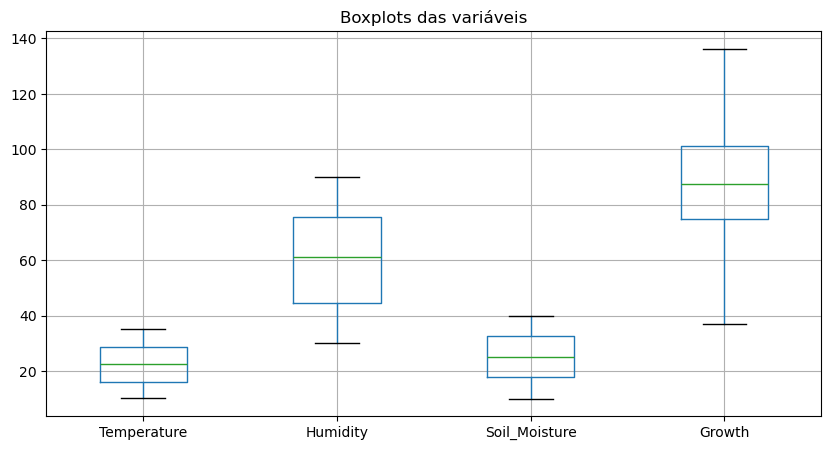

In [29]:
df.boxplot(figsize=(10, 5))
plt.title('Boxplots das variáveis')
plt.show()

### Q1.3 — Seleção de preditores (X) e alvo (y)

As três variáveis de sensor tornam-se a matriz de preditores `X`; o crescimento (`Growth`) é a variável-alvo `y`.


In [30]:
X = df[["Temperature", "Humidity", "Soil_Moisture"]]
y = df["Growth"]

print(f"X: {X.shape[0]} amostras x {X.shape[1]} preditores")
print(f"y: alvo 'Growth' com {y.shape[0]} valores")

X: 1000 amostras x 3 preditores
y: alvo 'Growth' com 1000 valores


### Observações — Q1

- O dataset tem **1000 amostras e 4 colunas**, todas `float64`, **sem valores ausentes e sem duplicatas** — o schema pandera confirmou a estrutura esperada e nenhuma etapa de limpeza foi necessária.
- O método IQR **não identificou outliers** em nenhuma variável, e os boxplots confirmam: todas as caixas aparecem sem pontos fora dos bigodes.
- Pelo `describe()`, as faixas são plausíveis para uma lavoura sensorizada: Temperature entre ~10 e ~35, Humidity entre ~30 e ~90, Soil_Moisture entre ~10 e ~40 e Growth entre ~37 e ~136.
- Em todas as variáveis a **média é muito próxima da mediana** (ex.: Growth 87.6 vs. 87.5), indicando distribuições aproximadamente **simétricas**, sem caudas distorcidas — mais um indício de que os dados não exigem tratamento adicional.
- Com os dados íntegros, definimos `X` = (Temperature, Humidity, Soil_Moisture) e `y` = Growth e seguimos para o treinamento.


## Q2 — Treinamento do Modelo (30%)

### Q2.1 — Separação treino/teste

`train_test_split` reserva **30% dos dados para teste** (nunca vistos no treinamento) e fixa o `random_state` para reprodutibilidade.


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 700 amostras
Teste:  300 amostras


### Q2.2 — Ajuste do modelo de Regressão Linear e previsão

`LinearRegression` do scikit-learn ajusta por mínimos quadrados o modelo
$\hat{y} = \beta_0 + \beta_1 \cdot Temperature + \beta_2 \cdot Humidity + \beta_3 \cdot Soil\_Moisture$.


In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred[:5]

array([98.7987147 , 83.48099461, 99.68262723, 87.5682644 , 77.64777097])

### Q2.3 — Coeficientes do modelo

Cada coeficiente indica a variação esperada no crescimento por unidade da variável, mantidas as demais constantes.


In [33]:
for nome, coef in zip(X.columns, model.coef_):
    print(f"Coeficiente de {nome}: {coef:.4f}")
print(f"Intercepto: {model.intercept_:.4f}")

Coeficiente de Temperature: 1.1876
Coeficiente de Humidity: 0.7728
Coeficiente de Soil_Moisture: 0.4919
Intercepto: 2.1989


### Observações — Q2

- A base foi dividida em **700 amostras de treino (70%) e 300 de teste (30%)**, com `random_state=42` para reprodutibilidade.
- O modelo ajustado foi:

$$\hat{Growth} = 2.20 + 1.19 \cdot Temperature + 0.77 \cdot Humidity + 0.49 \cdot Soil\_Moisture$$

- Todos os coeficientes são **positivos**: mantidas as demais variáveis constantes, +1 unidade de temperatura associa-se a **+1.19** de crescimento, +1 de umidade do ar a **+0.77** e +1 de umidade do solo a **+0.49**. Faz sentido agronomicamente: calor e água (no ar e no solo) favorecem o desenvolvimento da cultura dentro das faixas observadas.
- Como as variáveis têm **escalas diferentes** (desvio-padrão: Humidity ≈ 17.5, Soil_Moisture ≈ 8.7, Temperature ≈ 7.3), comparar coeficientes brutos pode enganar. Multiplicando cada coeficiente pelo desvio-padrão da variável (efeito prático de "1 desvio-padrão de variação"), a **umidade do ar é a variável de maior impacto** (≈ 13.5 pontos de Growth), seguida da temperatura (≈ 8.7) e da umidade do solo (≈ 4.3).
- O intercepto (2.20) tem pouca interpretação prática: corresponde a um cenário fora das faixas observadas (todas as variáveis em zero).


## Q3 — Avaliação das Métricas e Interpretação (40%)

### Q3.1 — Métricas de desempenho

- **R²** — proporção da variância de `Growth` explicada pelo modelo (quanto mais próximo de 1, melhor);
- **MSE** — erro quadrático médio (penaliza grandes erros; unidade ao quadrado);
- **RMSE** — raiz do MSE, na mesma unidade do alvo, facilitando a interpretação.


In [34]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R²:   {r2:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

R²:   0.9241
MSE:  24.8928
RMSE: 4.9893


### Q3.2 — Visualizações

**Figura 1 — dispersão do crescimento vs. cada preditor com reta de tendência** (regressão simples ilustrativa por variável).


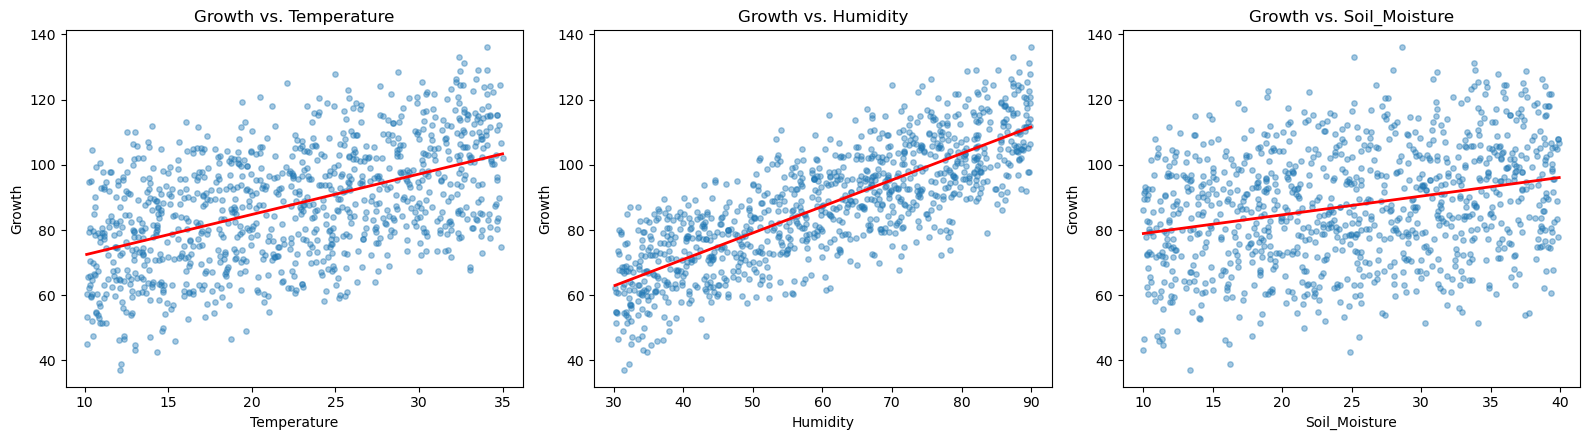

In [35]:
features = ["Temperature", "Humidity", "Soil_Moisture"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, feature in zip(axes, features):
    ax.scatter(df[feature], df["Growth"], alpha=0.4, s=15)
    a, b = np.polyfit(df[feature], df["Growth"], 1)
    x_lin = np.linspace(df[feature].min(), df[feature].max(), 100)
    ax.plot(x_lin, a * x_lin + b, color='red', linewidth=2)
    ax.set_xlabel(feature)
    ax.set_ylabel('Growth')
    ax.set_title(f'Growth vs. {feature}')
plt.tight_layout()
plt.show()

**Figura 2 — valores previstos vs. reais** (pontos sobre a reta tracejada = previsão perfeita) e **resíduos vs. valores previstos** (resíduos dispersos aleatoriamente ao redor de zero indicam bom ajuste).


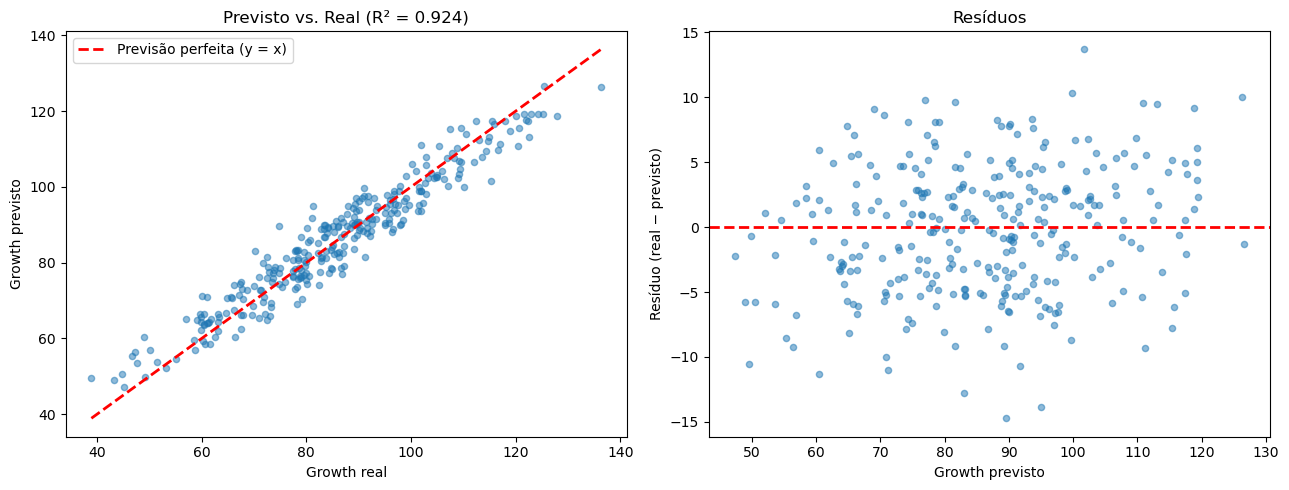

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5, s=20)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Previsão perfeita (y = x)')
axes[0].set_xlabel('Growth real')
axes[0].set_ylabel('Growth previsto')
axes[0].set_title(f'Previsto vs. Real (R² = {r2:.3f})')
axes[0].legend()

residuos = y_test - y_pred
axes[1].scatter(y_pred, residuos, alpha=0.5, s=20)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Growth previsto')
axes[1].set_ylabel('Resíduo (real − previsto)')
axes[1].set_title('Resíduos')

plt.tight_layout()
plt.show()

### Conclusões — Q3

**Qualidade do ajuste.** O modelo atingiu **R² = 0.924**: as três variáveis de sensor explicam cerca de **92% da variabilidade do crescimento** — um ajuste excelente para um modelo linear simples. O MSE foi 24.89 e o **RMSE ≈ 4.99**: o erro típico de previsão é de 5 unidades de Growth, apenas **~5.7% da média** (87.6) e uma fração pequena da amplitude dos dados (~37 a ~136).

**Comportamento das variáveis (Figura 1).** O crescimento aumenta com as três variáveis, mas com intensidades diferentes: a correlação linear é **forte com Humidity (r ≈ 0.79)**, moderada com Temperature (r ≈ 0.50) e fraca com Soil_Moisture (r ≈ 0.28). A umidade do ar é, sozinha, o melhor preditor — coerente com o maior efeito prático estimado na Q2. Já a umidade do solo, apesar da correlação individual fraca, ainda adiciona informação útil no modelo múltiplo (seu coeficiente continua positivo e significativo no ajuste conjunto).

**Resíduos (Figura 2).** Os pontos previstos vs. reais concentram-se ao longo da reta de previsão perfeita (y = x), e os resíduos se dispersam **aleatoriamente ao redor de zero**, sem formato de funil (variância aproximadamente constante) nem curvatura sistemática — indícios de que a forma linear é adequada para esses dados.

**Limitações e melhorias.**
- Os dados são observacionais, então correlação não implica causalidade.
-  Foi utilizada uma única divisão treino/teste; a validação cruzada daria uma estimativa mais estável do erro.
